# Project
Analyze the California Housing dataset to predict median house values, comparing the performance of various regression models including Linear Regression, Random Forest, Gradient Boosting, and Ridge Regression with polynomial features, highlighting the impact of feature engineering and hyperparameter tuning, and summarizing key findings and next steps.

## Organize Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

## Load and Preprocess Data


In [25]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Handle duplicates and missing values
print(f"Shape before cleaning: {df.shape}")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f"Shape after cleaning: {df.shape}")

# Select features (X) and target (y)
features = ['MedInc', 'AveRooms', 'HouseAge', 'Latitude', 'Longitude']
X = df[features]
y = df['MedHouseVal']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Shape before cleaning: (20640, 9)
Shape after cleaning: (20640, 9)

Features (X) shape: (20640, 5)
Target (y) shape: (20640,)


## Exploratory Data Analysis (EDA) - Correlation Matrix


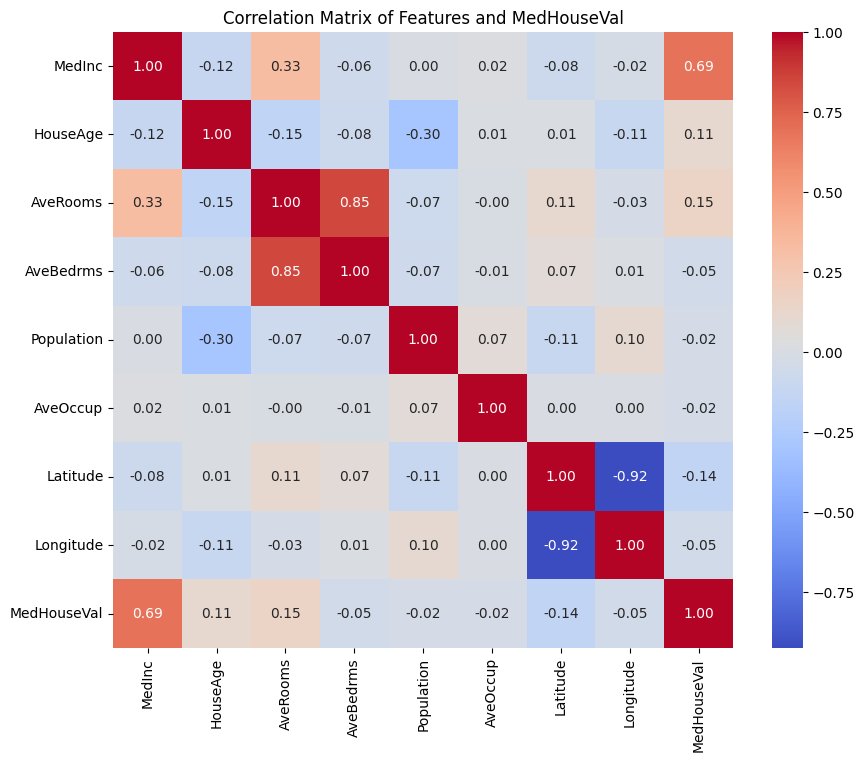

In [26]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and MedHouseVal')
plt.show()

## Data Splitting and Scaling



In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (16512, 5)
Shape of X_test_scaled: (4128, 5)


## Model Training and Evaluation - Base Models



In [28]:
print("=== Linear Regression ===")
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)
r2_lin = r2_score(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
print(f"R² Linear Regression: {r2_lin:.4f}")
print(f"MSE Linear Regression: {mse_lin:.4f}")

print("\n=== Random Forest Regressor ===")
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf = rf_reg.predict(X_test_scaled)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"R² Random Forest: {r2_rf:.4f}")
print(f"MSE Random Forest: {mse_rf:.4f}")

print("\n=== Gradient Boosting Regressor ===")
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_scaled, y_train)
y_pred_gb = gb_reg.predict(X_test_scaled)
r2_gb = r2_score(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
print(f"R² Gradient Boosting: {r2_gb:.4f}")
print(f"MSE Gradient Boosting: {mse_gb:.4f}")

=== Linear Regression ===
R² Linear Regression: 0.5814
MSE Linear Regression: 0.5486

=== Random Forest Regressor ===
R² Random Forest: 0.8090
MSE Random Forest: 0.2503

=== Gradient Boosting Regressor ===
R² Gradient Boosting: 0.7488
MSE Gradient Boosting: 0.3292


## Feature Engineering - Polynomial Features and Ridge Regression



In [29]:
print("\n=== Ridge Regression with Polynomial Features ===")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(X_train_poly, y_train)

y_pred_ridge_poly = ridge_poly.predict(X_test_poly)
r2_ridge_poly = r2_score(y_test, y_pred_ridge_poly)
mse_ridge_poly = mean_squared_error(y_test, y_pred_ridge_poly)

print(f"R² Ridge Polynomial: {r2_ridge_poly:.4f}")
print(f"MSE Ridge Polynomial: {mse_ridge_poly:.4f}")


=== Ridge Regression with Polynomial Features ===
R² Ridge Polynomial: 0.6062
MSE Ridge Polynomial: 0.5160


## Hyperparameter Tuning for Random Forest


In [30]:
print("\n=== Hyperparameter Tuning for Random Forest ===")

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="r2"
)

grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur R² (validation croisée) :", grid_search.best_score_)

print("\n=== Tuned Random Forest Regressor Evaluation ===")

# Make predictions on the scaled test data using the best_rf estimator
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

# Calculate R² score and Mean Squared Error
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)

print(f"R² Tuned Random Forest: {r2_rf_tuned:.4f}")
print(f"MSE Tuned Random Forest: {mse_rf_tuned:.4f}")


=== Hyperparameter Tuning for Random Forest ===
Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Meilleur R² (validation croisée) : 0.7667646522778653

=== Tuned Random Forest Regressor Evaluation ===
R² Tuned Random Forest: 0.7635
MSE Tuned Random Forest: 0.3099


## Final Model Evaluation and Comparison


=== Model R² Score Comparison ===
                      Model  R² Score
0         Linear Regression  0.581374
1      Random Forest (Base)  0.808988
2         Gradient Boosting  0.748770
3  Ridge with Poly Features  0.606201
4     Random Forest (Tuned)  0.763520


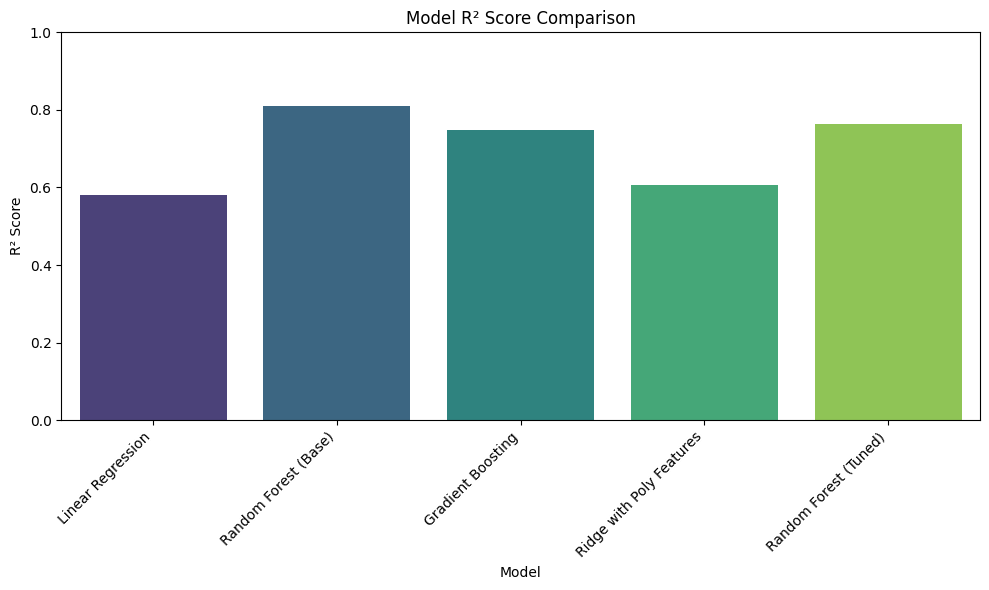

In [31]:
model_r2_scores = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest (Base)",
        "Gradient Boosting",
        "Ridge with Poly Features",
        "Random Forest (Tuned)"
    ],
    "R² Score": [
        r2_lin,
        r2_rf,
        r2_gb,
        r2_ridge_poly,
        r2_rf_tuned
    ]
})

print("=== Model R² Score Comparison ===")
print(model_r2_scores)

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R² Score", hue="Model", data=model_r2_scores, palette="viridis", legend=False)
plt.ylim(0, 1) # R² scores range from 0 to 1
plt.title("Model R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Save Best Model


In [32]:
filename = 'model.pkl'
pickle.dump(best_rf, open(filename, 'wb'))

print(f"Best model saved to {filename}")

Best model saved to model.pkl


## Summary:

### Data Analysis Key Findings

*   **Top Performing Model**: The base Random Forest Regressor demonstrated the highest performance with an R² score of 0.8090 and the lowest Mean Squared Error (MSE) of 0.2503 among all models tested, prior to hyperparameter tuning.
*   **Impact of Hyperparameter Tuning**: Hyperparameter tuning for the Random Forest Regressor, using `GridSearchCV`, resulted in optimal parameters `{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}`. However, the R² score for the tuned Random Forest on the test set was 0.7635 (MSE: 0.3099), which was slightly lower than the base Random Forest's performance of 0.8090.
*   **Impact of Feature Engineering (Polynomial Features)**: Generating polynomial features of degree 2 and applying Ridge Regression improved the R² score to 0.6062 (MSE: 0.5160) compared to the base Linear Regression model's R² of 0.5814 (MSE: 0.5486), indicating a modest positive impact on model performance.
*   **Base Model Performance Comparison**:
    *   Linear Regression: R² of 0.5814, MSE of 0.5486.
    *   Random Forest (Base): R² of 0.8090, MSE of 0.2503.
    *   Gradient Boosting: R² of 0.7488, MSE of 0.3292.
*   **Correlation Matrix's Role**: The correlation matrix visualization aided in understanding the relationships between features and the target variable, `MedHouseVal`, providing initial insights into which features might be more predictive and identifying potential multicollinearity or feature groupings.

